# Single-Pulse Analysis

Analyzes single-electrode stimulation results from `closed_loop_no_encoder_500msinterval_DEBUG`.
PCA is fit on visual orientation epoch vectors (same basis as `analyze_closed_loop_results.ipynb`).

In [1]:
import os
import pickle
import json
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as mcm
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from sklearn.decomposition import PCA

# ── Paths ──────────────────────────────────────────────────────────────────
DATA_DIR = "outputs/data_system_sim_0.05scale/closed_loop_no_encoder_500msinterval_multiamp_DEBUG"
VIS_DIR  = "outputs/data_system_sim_0.05scale/visual_orientations_8"

VIZ_DIR = os.path.join(DATA_DIR, "viz")
os.makedirs(VIZ_DIR, exist_ok=True)

N_STIM_CHANNELS = 32

# ── Load experiment config + history ──────────────────────────────────────
config_json = os.path.join(DATA_DIR, "closed_loop_no_encoder_config.json")
config_pkl  = os.path.join(DATA_DIR, "closed_loop_no_encoder_config.pkl")
if os.path.isfile(config_json):
    with open(config_json) as f:
        config = json.load(f)
else:
    with open(config_pkl, "rb") as f:
        config = pickle.load(f)

with open(os.path.join(DATA_DIR, "closed_loop_no_encoder_history.pkl"), "rb") as f:
    history = pickle.load(f)

print("Config keys:", list(config.keys()))
print(f"History entries: {len(history)}")
print("Example history entry:", history[1])

Config keys: ['total_duration_ms', 'closed_loop_interval_ms', 'bin_ms', 'n_stim_channels', 'n_repertoire', 'n_trials', 'stim_amplitudes_uA', 'visual_metadata_path', 'data_path', 'results']
History entries: 965
Example history entry: {'interval_index': 1, 'interval_start_ms': 500.0, 'interval_end_ms': 1000.0, 'n_new_spikes': 1734, 'actual_l2': 61.5629768371582, 'delivered_pattern': {'channels': array([0]), 'times_ms': array([0.]), 'amplitudes_uA': array([1.])}}


In [2]:
# ── Fit PCA on visual-orientation epoch vectors ────────────────────────────
# Same procedure as analyze_closed_loop_results.ipynb — PCA basis is shared.

with open(os.path.join(VIS_DIR, "visual8_spike_rates.pkl"), "rb") as f:
    vis_rates = pickle.load(f)
with open(os.path.join(VIS_DIR, "visual8_run_config.pkl"), "rb") as f:
    vis_config = pickle.load(f)

sample_info      = vis_config["sample_info"]
vis_centers_ms   = np.arange(vis_rates.shape[0]) * 100.0 + 250.0
orientations_deg = sorted(set(s[2] for s in sample_info))

epoch_vectors, epoch_angles = [], []
for start_ms, end_ms, angle_deg, _ in sample_info:
    mask = (vis_centers_ms >= start_ms) & (vis_centers_ms < end_ms)
    if mask.sum() == 0:
        continue
    epoch_vectors.append(vis_rates[mask].mean(axis=0))
    epoch_angles.append(angle_deg)
epoch_vectors = np.array(epoch_vectors)
epoch_angles  = np.array(epoch_angles)

avg_vectors = np.array([epoch_vectors[epoch_angles == a].mean(axis=0) for a in orientations_deg])
avg_angles  = np.array(orientations_deg)

pca = PCA(n_components=3)
pca.fit(epoch_vectors)
avg_pca   = pca.transform(avg_vectors)
epoch_pca = pca.transform(epoch_vectors)
n_pca_neurons = epoch_vectors.shape[1]
print(f"Explained variance (PC1-3): {pca.explained_variance_ratio_.round(3)}")

# Visual response mean = PCA origin (mean of the visual training distribution).
# pca.transform(pca.mean_[None, :])[0] is identically [0, 0, 0] by construction.
vis_mean_pc = np.zeros(3)

# Orientation colormap
ori_cmap   = plt.get_cmap("hsv")
ori_colors = {a: ori_cmap(i / len(orientations_deg)) for i, a in enumerate(orientations_deg)}

Explained variance (PC1-3): [0.074 0.064 0.052]


In [3]:
# ── Load single-pulse spike data ───────────────────────────────────────────

d = np.load(os.path.join(DATA_DIR, "closed_loop_no_encoder_spike_bins.npz"))
bin_ms         = float(d["bin_ms"])
spike_bins_arr = d["spike_bins"].astype(np.float32)  # (n_intervals, bpi, n_neurons)
n_intervals, bpi, n_neurons = spike_bins_arr.shape
print(f"spike_bins shape: {spike_bins_arr.shape}  (bin_ms={bin_ms})")

with open(os.path.join(DATA_DIR, "closed_loop_no_encoder_spike_counts.pkl"), "rb") as f:
    spike_counts_matrix = pickle.load(f)   # (n_intervals, n_neurons)
print(f"spike_counts_matrix shape: {spike_counts_matrix.shape}")

# Trial structure — config stores n_repertoire = n_channels x n_amplitudes + 1
n_repertoire = int(config.get("n_repertoire", N_STIM_CHANNELS + 1))
n_trials     = int(config.get("n_trials", n_intervals // n_repertoire))
interval_ms  = float(config.get("closed_loop_interval_ms", 500.0))
# stim_amplitudes_uA stored as list in new runs; fall back to scalar for old runs
_amps_cfg = config.get("stim_amplitudes_uA", config.get("stim_amplitude_uA", 2.0))
stim_amplitudes_cfg = _amps_cfg if isinstance(_amps_cfg, list) else [_amps_cfg]
print(f"n_repertoire={n_repertoire}, n_trials={n_trials}, n_intervals={n_intervals}")
print(f"stim_amplitudes_uA={stim_amplitudes_cfg} uA")

# Mean firing rate (Hz) over each full interval: (n_intervals, n_neurons)
interval_hz = spike_bins_arr[:, :, :n_pca_neurons].mean(axis=1) / bin_ms

# Project all intervals into PC space
all_pc = pca.transform(interval_hz)  # (n_intervals, 3)

# Spontaneous activity baseline: no stimulation is delivered in any no-stim slot,
# so all of them are clean spontaneous. Average over all no-stim intervals.
no_stim_idx = [i for i, h in enumerate(history) if h.get("delivered_pattern") is None]

spont_hz = spike_bins_arr[no_stim_idx, :, :n_pca_neurons].mean(axis=(0, 1)) / bin_ms
spont_pc = pca.transform(spont_hz[None, :])[0]
no_stim_pc = np.array([-1.36127253e-02, -6.54527467e-03, 3.35263542e-05]).astype(np.float32) # from long no-stimulation run, hardcoded bc Claude was being a doofus

print(f"Spontaneous mean: averaged over {len(no_stim_idx)} no-stim intervals ({n_trials} trials)")
print(f"  spont_pc    = {spont_pc.round(4)}")
print (f" long no-stim run spont_pc = {no_stim_pc.round(4)}")
print(f"  vis_mean_pc = {vis_mean_pc}")
print (f"Distance from spontaneous baseline to no-stim in PC space: {np.linalg.norm(no_stim_pc - spont_pc):.4f}")



spike_bins shape: (965, 100, 3858)  (bin_ms=5.0)
spike_counts_matrix shape: (965, 3858)
n_repertoire=193, n_trials=5, n_intervals=965
stim_amplitudes_uA=[1.0, 2.0, 3.0, 4.0, 5.0, 6.0] uA
Spontaneous mean: averaged over 5 no-stim intervals (5 trials)
  spont_pc    = [-0.0171 -0.0077 -0.0007]
 long no-stim run spont_pc = [-0.0136 -0.0065  0.    ]
  vis_mean_pc = [0. 0. 0.]
Distance from spontaneous baseline to no-stim in PC space: 0.0037


In [4]:
# ── Collect pre→post shift vectors per electrode ───────────────────────────
#
# For interval i with a delivered pattern:
#   pre  = PC projection of interval i-1
#   post = PC projection of interval i
#   shift = post - pre

shifts_by_ch   = defaultdict(list)   # ch -> list of (pre_pc, post_pc)
shifts_no_stim = []                  # no-stim intervals

for i, h in enumerate(history):
    if i == 0:
        continue
    pat     = h.get("delivered_pattern")
    pre_pc  = all_pc[i - 1]
    post_pc = all_pc[i]
    if pat is not None and len(pat.get("channels", [])) > 0:
        ch = int(pat["channels"][0])
        shifts_by_ch[ch].append((pre_pc, post_pc))
    else:
        shifts_no_stim.append((pre_pc, post_pc))

print(f"Electrodes with data: {sorted(shifts_by_ch.keys())}")
print(f"No-stim intervals: {len(shifts_no_stim)}")
print(f"Stim intervals: {sum(len(v) for v in shifts_by_ch.values())}")

Electrodes with data: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31]
No-stim intervals: 4
Stim intervals: 960


/var/folders/38/_qz39whn0hngmtsmjg9byfbr0000gn/T/ipykernel_39390/3777144976.py:78: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  sm = mcm.ScalarMappable(cmap=mcm.get_cmap("hsv"),


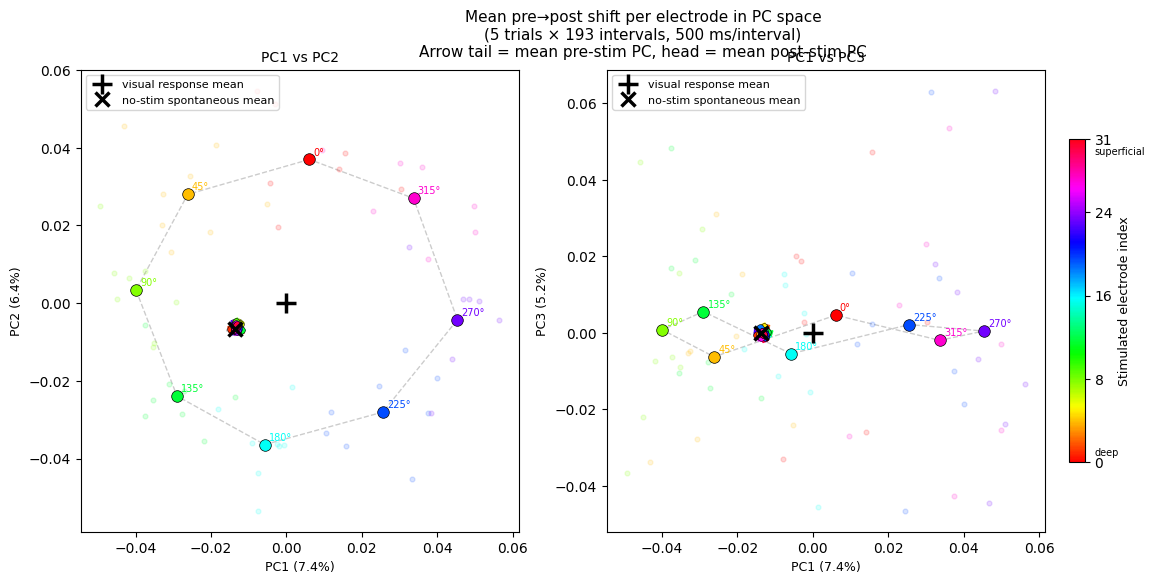

Saved → outputs/data_system_sim_0.05scale/closed_loop_no_encoder_500msinterval_multiamp_DEBUG/viz/single_pulse_shift_arrows_pca.png


In [11]:
# ── PC-space shift arrows: mean pre→post per electrode ─────────────────────

ch_cmap   = mcm.hsv(np.linspace(0, 1, N_STIM_CHANNELS, endpoint=False))
ch_colors = {ch: ch_cmap[ch] for ch in range(N_STIM_CHANNELS)}

def mean_shift(pairs):
    diffs = np.array([post - pre for pre, post in pairs])
    return diffs.mean(axis=0), diffs.std(axis=0)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle(
    f"Mean pre→post shift per electrode in PC space\n"
    f"({n_trials} trials × {n_repertoire} intervals, {interval_ms:.0f} ms/interval)\n"
    f"Arrow tail = mean pre-stim PC, head = mean post-stim PC",
    fontsize=11,
)

for ax, (pc_x, pc_y) in zip(axes, [(0, 1), (0, 2)]):
    # Orientation ring
    ring_ord = np.argsort(avg_angles)
    ax.plot(
        np.append(avg_pca[ring_ord, pc_x], avg_pca[ring_ord[0], pc_x]),
        np.append(avg_pca[ring_ord, pc_y], avg_pca[ring_ord[0], pc_y]),
        "--", color="grey", lw=1.0, alpha=0.4, zorder=1,
    )
    for ang in sorted(set(avg_angles.tolist())):
        m = epoch_angles == ang
        ax.scatter(epoch_pca[m, pc_x], epoch_pca[m, pc_y],
                   color=ori_colors[ang], s=12, alpha=0.15, zorder=2)
    for j, ang in enumerate(avg_angles):
        ax.scatter(avg_pca[j, pc_x], avg_pca[j, pc_y],
                   color=ori_colors[ang], s=70, edgecolors="k", lw=0.5, zorder=3)
        ax.annotate(f"{int(ang)}°",
                    xy=(avg_pca[j, pc_x], avg_pca[j, pc_y]),
                    xytext=(3, 3), textcoords="offset points",
                    fontsize=7, color=ori_colors[ang])

    # ── Reference markers ────────────────────────────────────────────────
    ax.plot(vis_mean_pc[pc_x], vis_mean_pc[pc_y],
            marker="+", markersize=14, markeredgewidth=2.5,
            color="black", linestyle="none", zorder=10,
            label="visual response mean")
    ax.plot(no_stim_pc[pc_x], no_stim_pc[pc_y],
            marker="x", markersize=10, markeredgewidth=2.5,
            color="black", linestyle="none", zorder=10,
            label="no-stim spontaneous mean")

    # No-stim arrow
    if shifts_no_stim:
        ns_pre  = np.mean([p for p, _ in shifts_no_stim], axis=0)
        ns_post = np.mean([p for _, p in shifts_no_stim], axis=0)
        ax.annotate("",
            xy=(ns_post[pc_x], ns_post[pc_y]),
            xytext=(ns_pre[pc_x], ns_pre[pc_y]),
            arrowprops=dict(arrowstyle="-|>", color="silver", lw=1.5),
            zorder=4)
        ax.scatter(ns_pre[pc_x], ns_pre[pc_y], color="silver", s=40,
                   edgecolors="k", lw=0.5, zorder=5)

    # Per-electrode shift arrows
    for ch, pairs in sorted(shifts_by_ch.items()):
        col       = ch_colors[ch]
        mean_pre  = np.mean([p for p, _ in pairs], axis=0)
        mean_post = np.mean([p for _, p in pairs], axis=0)
        ax.annotate("",
            xy=(mean_post[pc_x], mean_post[pc_y]),
            xytext=(mean_pre[pc_x], mean_pre[pc_y]),
            arrowprops=dict(arrowstyle="-|>", color=col, lw=1.4),
            zorder=6)
        ax.scatter(mean_pre[pc_x], mean_pre[pc_y], color=col, s=30,
                   edgecolors="k", lw=0.4, zorder=7)

    ax.set_xlabel(f"PC{pc_x+1} ({pca.explained_variance_ratio_[pc_x]:.1%})", fontsize=9)
    ax.set_ylabel(f"PC{pc_y+1} ({pca.explained_variance_ratio_[pc_y]:.1%})", fontsize=9)
    ax.set_title(f"PC{pc_x+1} vs PC{pc_y+1}", fontsize=10)
    ax.legend(fontsize=8, loc="upper left")

sm = mcm.ScalarMappable(cmap=mcm.get_cmap("hsv"),
                         norm=plt.Normalize(vmin=0, vmax=N_STIM_CHANNELS - 1))
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes, shrink=0.7, pad=0.02)
cbar.set_label("Stimulated electrode index", fontsize=9)
cbar.set_ticks([0, 8, 16, 24, 31])
cbar.ax.annotate("deep",        xy=(1.6, 0.02), xycoords="axes fraction", fontsize=7)
cbar.ax.annotate("superficial", xy=(1.6, 0.95), xycoords="axes fraction", fontsize=7)

out = os.path.join(VIZ_DIR, "single_pulse_shift_arrows_pca.png")
plt.savefig(out, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved → {out}")

In [12]:
# ── Shift magnitude per electrode ──────────────────────────────────────────

print("Mean shift magnitude (PC1-2 norm) per electrode:")
mags = {}
for ch, pairs in sorted(shifts_by_ch.items()):
    diffs = np.array([post[:2] - pre[:2] for pre, post in pairs])
    mags[ch] = diffs.mean(axis=0)
    print(f"  ch{ch:02d}: |shift|={np.linalg.norm(mags[ch]):.4f}  (n={len(pairs)})")

if shifts_no_stim:
    ns_diffs = np.array([post[:2] - pre[:2] for pre, post in shifts_no_stim])
    ns_mag   = np.linalg.norm(ns_diffs.mean(axis=0))
    print(f"  no-stim: |shift|={ns_mag:.4f}  (n={len(shifts_no_stim)})")

Mean shift magnitude (PC1-2 norm) per electrode:
  ch00: |shift|=0.0009  (n=30)
  ch01: |shift|=0.0023  (n=30)
  ch02: |shift|=0.0003  (n=30)
  ch03: |shift|=0.0013  (n=30)
  ch04: |shift|=0.0012  (n=30)
  ch05: |shift|=0.0013  (n=30)
  ch06: |shift|=0.0019  (n=30)
  ch07: |shift|=0.0009  (n=30)
  ch08: |shift|=0.0014  (n=30)
  ch09: |shift|=0.0020  (n=30)
  ch10: |shift|=0.0013  (n=30)
  ch11: |shift|=0.0016  (n=30)
  ch12: |shift|=0.0013  (n=30)
  ch13: |shift|=0.0010  (n=30)
  ch14: |shift|=0.0002  (n=30)
  ch15: |shift|=0.0006  (n=30)
  ch16: |shift|=0.0013  (n=30)
  ch17: |shift|=0.0010  (n=30)
  ch18: |shift|=0.0008  (n=30)
  ch19: |shift|=0.0011  (n=30)
  ch20: |shift|=0.0013  (n=30)
  ch21: |shift|=0.0009  (n=30)
  ch22: |shift|=0.0011  (n=30)
  ch23: |shift|=0.0006  (n=30)
  ch24: |shift|=0.0009  (n=30)
  ch25: |shift|=0.0018  (n=30)
  ch26: |shift|=0.0010  (n=30)
  ch27: |shift|=0.0005  (n=30)
  ch28: |shift|=0.0007  (n=30)
  ch29: |shift|=0.0009  (n=30)
  ch30: |shift|=0.000

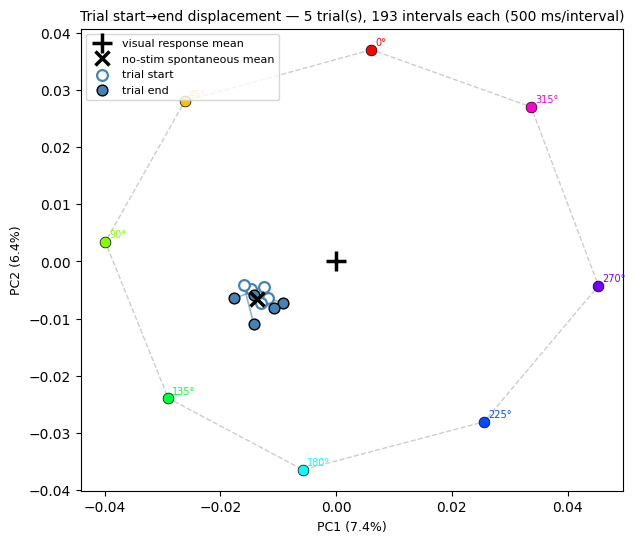

Saved -> outputs/data_system_sim_0.05scale/closed_loop_no_encoder_500msinterval_multiamp_DEBUG/viz/trial_start_end_vectors.png


In [13]:
# ── Per-trial start→end vectors in PC space ───────────────────────────────
# Each trial is shown as a straight line from its first to its last interval.
# All trials overlay in the same color.
#
# TRIALS_TO_PLOT: list of trial indices, or None to show all trials.

TEST_CURRENT = 4
TEST_ELECTRODE = 12
trials = []
for t in range(len(history)):
    pat = history[t]["delivered_pattern"]
    if pat is not None:
        ch = pat["channels"][0]
        amp = pat["amplitudes_uA"][0]
        if ch == TEST_ELECTRODE and amp == TEST_CURRENT:
            trials.append(t)
if len(trials) == 0:
    trials = None


fig, ax = plt.subplots(figsize=(7, 6))

# Orientation ring
ring_ord = np.argsort(avg_angles)
ax.plot(
    np.append(avg_pca[ring_ord, 0], avg_pca[ring_ord[0], 0]),
    np.append(avg_pca[ring_ord, 1], avg_pca[ring_ord[0], 1]),
    "--", color="grey", lw=1.0, alpha=0.4,
)
for j, ang in enumerate(avg_angles):
    ax.scatter(avg_pca[j, 0], avg_pca[j, 1],
               color=ori_colors[ang], s=60, edgecolors="k", lw=0.5, zorder=3)
    ax.annotate(f"{int(ang)}°",
                xy=(avg_pca[j, 0], avg_pca[j, 1]),
                xytext=(3, 3), textcoords="offset points",
                fontsize=7, color=ori_colors[ang])

# Reference markers
ax.plot(vis_mean_pc[0], vis_mean_pc[1],
        marker="+", markersize=14, markeredgewidth=2.5,
        color="black", linestyle="none", zorder=10,
        label="visual response mean")
ax.plot(no_stim_pc[0], no_stim_pc[1],
        marker="x", markersize=10, markeredgewidth=2.5,
        color="black", linestyle="none", zorder=10,
        label="no-stim spontaneous mean")

# One line per trial: start (open circle) → end (filled circle)
for t in trials:
    p_start = all_pc[t] # TODO: replace with instant spike PC projection at trial start vs. trial end. 
    p_end   = all_pc[t - 1]
    ax.plot([p_start[0], p_end[0]], [p_start[1], p_end[1]],
            color="steelblue", lw=1.2, alpha=0.6, zorder=5)
    label_s = "trial start" if t == trials[0] else None
    label_e = "trial end"   if t == trials[0] else None
    ax.scatter(p_start[0], p_start[1], color="white", s=60,
               edgecolors="steelblue", lw=1.6, zorder=7, label=label_s)
    ax.scatter(p_end[0],   p_end[1],   color="steelblue", s=60,
               edgecolors="k", lw=1.0, zorder=7, label=label_e)

ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})", fontsize=9)
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})", fontsize=9)
ax.set_title(
    f"Trial start→end displacement — {len(trials)} trial(s), "
    f"{n_repertoire} intervals each ({interval_ms:.0f} ms/interval)",
    fontsize=10,
)
ax.legend(fontsize=8, loc="upper left")

out = os.path.join(VIZ_DIR, "trial_start_end_vectors.png")
plt.savefig(out, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved -> {out}")

bin_ms=5.0  offset_bins=40  obs_bins=8
Window: t=[200 … 240] ms post-stim onset

Electrodes: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31]
Amplitudes: [1.0, 2.0, 3.0, 4.0, 5.0, 6.0] uA
N_e=32  N_a=6  N_t=exactly 5 trials/pair


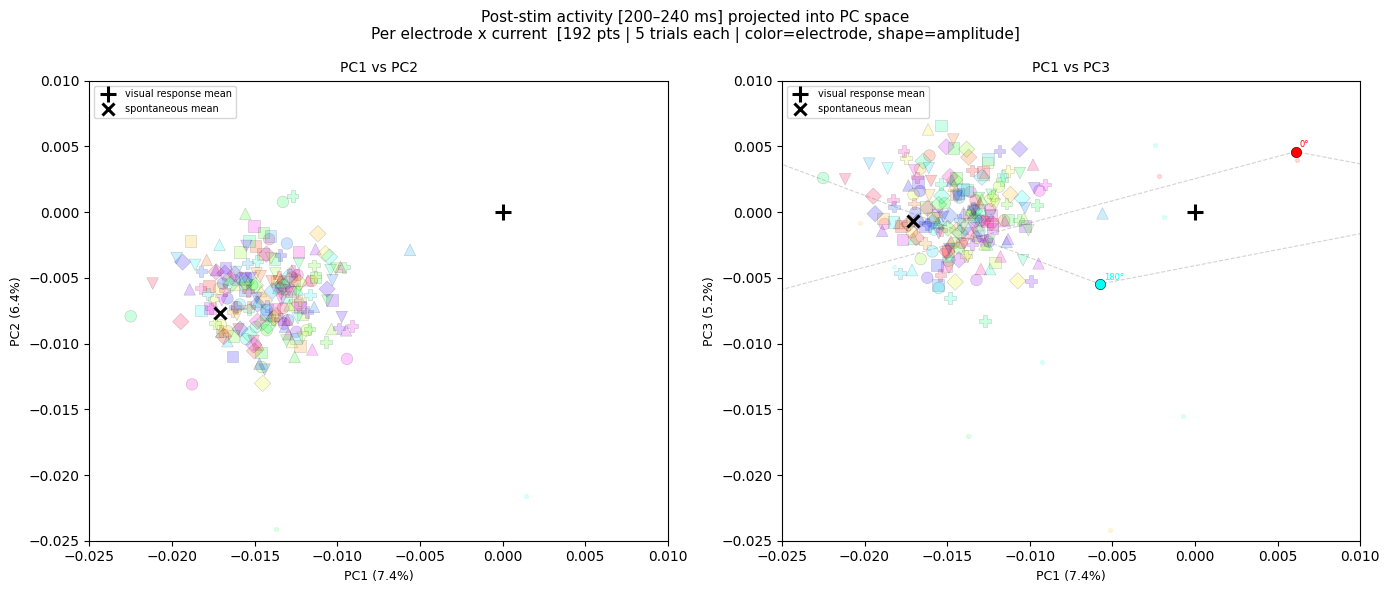

Saved -> outputs/data_system_sim_0.05scale/closed_loop_no_encoder_500msinterval_multiamp_DEBUG/viz/single_pulse_obs_window_ch_amp.png


In [ ]:
# ── Observation-window averages projected into PC space ─────────────────────
#
# Mirrors explore_sta.ipynb:
#   OBS_WINDOW_MS — duration of post-stim window to average (ms)
#   OFFSET_MS     — start of window relative to stim onset (ms); skip artifact
#
# PLOT_MODE controls what gets plotted (one panel, 2 PC projections):
#   "ch_amp"    — one point per (electrode × amplitude): N_e × N_a points
#                 color = electrode, shape = amplitude
#   "electrode" — one point per electrode (marginalised over amplitude): N_e points
#                 color = electrode, single marker shape
#   "current"   — one point per amplitude (marginalised over electrode): N_a points
#                 color = amplitude, single marker shape

PLOT_MODE     = "ch_amp"   # "ch_amp" | "electrode" | "current"
OBS_WINDOW_MS = 70.0       # ms of post-stim window to average
OFFSET_MS     = 0.0        # ms after stim onset before window starts

offset_bins = int(OFFSET_MS     / bin_ms)
obs_bins    = int(OBS_WINDOW_MS / bin_ms)
print(f"bin_ms={bin_ms}  offset_bins={offset_bins}  obs_bins={obs_bins}")
print(f"Window: t=[{OFFSET_MS:.0f} … {OFFSET_MS + OBS_WINDOW_MS:.0f}] ms post-stim onset")

# ── Collect per-(ch, amp) trial vectors ───────────────────────────────────
obs_by_ch_amp = defaultdict(list)   # (ch, amp) -> list of (n_pca_neurons,) Hz vecs

for i, h in enumerate(history):
    pat = h.get("delivered_pattern")
    if pat is None or len(pat.get("channels", [])) == 0:
        continue
    win = spike_bins_arr[i, offset_bins : offset_bins + obs_bins, :n_pca_neurons]
    if win.shape[0] < obs_bins:
        continue   # window shorter than requested — skip
    obs_hz = win.mean(axis=0) / bin_ms   # (n_pca_neurons,) Hz
    ch  = int(pat["channels"][0])
    amp = float(pat["amplitudes_uA"][0])
    obs_by_ch_amp[(ch, amp)].append(obs_hz)

all_amps = sorted(set(amp for ch, amp in obs_by_ch_amp))
all_chs  = sorted(set(ch  for ch, amp in obs_by_ch_amp))
N_e, N_a = len(all_chs), len(all_amps)

# Trial counts per pair — with round-robin repertoire these are always equal
trials_per_pair = {key: len(vecs) for key, vecs in obs_by_ch_amp.items()}
counts = list(trials_per_pair.values())
N_t    = counts[0] if len(set(counts)) == 1 else int(np.median(counts))
exact  = len(set(counts)) == 1

print(f"\nElectrodes: {all_chs}")
print(f"Amplitudes: {all_amps} uA")
print(f"N_e={N_e}  N_a={N_a}  N_t={'exactly' if exact else 'approx'} {N_t} trials/pair")

# ── Compute PC coords for each grouping ───────────────────────────────────
avg_ch_amp_pc = {}   # (ch, amp) -> (3,)
for key, vecs in obs_by_ch_amp.items():
    avg_ch_amp_pc[key] = pca.transform(np.stack(vecs).mean(axis=0)[None])[0]

avg_electrode_pc = {}   # ch -> (3,)
for ch in all_chs:
    vecs = [v for (c, a), vlist in obs_by_ch_amp.items() if c == ch for v in vlist]
    avg_electrode_pc[ch] = pca.transform(np.stack(vecs).mean(axis=0)[None])[0]

avg_current_pc = {}   # amp -> (3,)
for amp in all_amps:
    vecs = [v for (c, a), vlist in obs_by_ch_amp.items() if a == amp for v in vlist]
    avg_current_pc[amp] = pca.transform(np.stack(vecs).mean(axis=0)[None])[0]

# ── Marker shapes for amplitude ────────────────────────────────────────────
_MARKER_POOL = ["o", "s", "^", "D", "v", "P", "X", "h", "*", "p"]
amp_markers  = {amp: _MARKER_POOL[i % len(_MARKER_POOL)] for i, amp in enumerate(all_amps)}

# Amplitude colormap (used in "current" mode)
AMP_CMAP = plt.cm.viridis
amp_norm = plt.Normalize(vmin=min(all_amps),
                         vmax=max(all_amps) if N_a > 1 else max(all_amps) + 1)
amp_col  = {amp: AMP_CMAP(amp_norm(amp)) for amp in all_amps}

# ── Helper: draw orientation ring + reference markers ─────────────────────
def _draw_bg(ax, pc_x, pc_y):
    ring_ord = np.argsort(avg_angles)
    ax.plot(
        np.append(avg_pca[ring_ord, pc_x], avg_pca[ring_ord[0], pc_x]),
        np.append(avg_pca[ring_ord, pc_y], avg_pca[ring_ord[0], pc_y]),
        "--", color="grey", lw=0.8, alpha=0.35, zorder=1,
    )
    for ang in sorted(set(avg_angles.tolist())):
        m = epoch_angles == ang
        ax.scatter(epoch_pca[m, pc_x], epoch_pca[m, pc_y],
                   color=ori_colors[ang], s=8, alpha=0.12, zorder=2)
    for j, ang in enumerate(avg_angles):
        ax.scatter(avg_pca[j, pc_x], avg_pca[j, pc_y],
                   color=ori_colors[ang], s=55, edgecolors="k", lw=0.4, zorder=3)
        ax.annotate(f"{int(ang)}°",
                    xy=(avg_pca[j, pc_x], avg_pca[j, pc_y]),
                    xytext=(3, 3), textcoords="offset points",
                    fontsize=6, color=ori_colors[ang])
    ax.plot(vis_mean_pc[pc_x], vis_mean_pc[pc_y],
            "+", ms=12, mew=2.2, color="black", zorder=9, label="visual response mean")
    ax.plot(no_stim_pc[pc_x], no_stim_pc[pc_y],
            "x", ms=9,  mew=2.2, color="black", zorder=9, label="no-stim spontaneous mean")

# ── Title ─────────────────────────────────────────────────────────────────
if PLOT_MODE == "ch_amp":
    mode_title = (f"Per electrode x current  "
                  f"[{N_e * N_a} pts | {N_t} trials each | color=electrode, shape=amplitude]")
elif PLOT_MODE == "electrode":
    mode_title = (f"Per electrode  (marginalised over amplitude)  "
                  f"[{N_e} pts | {N_t * N_a} trials each | color=electrode]")
elif PLOT_MODE == "current":
    mode_title = (f"Per current  (marginalised over electrode)  "
                  f"[{N_a} pts | {N_t * N_e} trials each | color=amplitude]")
else:
    raise ValueError(f"PLOT_MODE must be 'ch_amp', 'electrode', or 'current'; got {PLOT_MODE!r}")

# ── Figure: 1 row x 2 cols ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(
    f"Post-stim activity [{OFFSET_MS:.0f}–{OFFSET_MS + OBS_WINDOW_MS:.0f} ms] projected into PC space\n"
    f"{mode_title}",
    fontsize=11,
)

for ax, (pc_x, pc_y) in zip(axes, [(0, 1), (0, 2)]):
    _draw_bg(ax, pc_x, pc_y)

    if PLOT_MODE == "ch_amp":
        for amp in all_amps:
            xs = [avg_ch_amp_pc[(ch, amp)][pc_x] for ch in all_chs if (ch, amp) in avg_ch_amp_pc]
            ys = [avg_ch_amp_pc[(ch, amp)][pc_y] for ch in all_chs if (ch, amp) in avg_ch_amp_pc]
            cs = [ch_colors[ch]                   for ch in all_chs if (ch, amp) in avg_ch_amp_pc]
            ax.scatter(xs, ys, c=cs, s=70, marker=amp_markers[amp],
                       edgecolors="k", lw=0.4, alpha=0.2, zorder=5)

    elif PLOT_MODE == "electrode":
        xs = [avg_electrode_pc[ch][pc_x] for ch in all_chs]
        ys = [avg_electrode_pc[ch][pc_y] for ch in all_chs]
        cs = [ch_colors[ch]              for ch in all_chs]
        ax.scatter(xs, ys, c=cs, s=80, marker="o",
                   edgecolors="k", lw=0.5, alpha=0.4, zorder=5)
        for ch in all_chs:
            pc = avg_electrode_pc[ch]
            ax.annotate(str(ch), xy=(pc[pc_x], pc[pc_y]),
                        xytext=(2, 2), textcoords="offset points", fontsize=6)

    elif PLOT_MODE == "current":
        for amp in all_amps:
            pc = avg_current_pc[amp]
            ax.scatter(pc[pc_x], pc[pc_y],
                       color=amp_col[amp], s=160, marker="D",
                       edgecolors="k", lw=0.7, zorder=5)
            ax.annotate(f"{amp} uA", xy=(pc[pc_x], pc[pc_y]),
                        xytext=(5, 3), textcoords="offset points",
                        fontsize=8, fontweight="bold")

    ax.set_xlabel(f"PC{pc_x+1} ({pca.explained_variance_ratio_[pc_x]:.1%})", fontsize=9)
    ax.set_ylabel(f"PC{pc_y+1} ({pca.explained_variance_ratio_[pc_y]:.1%})", fontsize=9)
    ax.set_title(f"PC{pc_x+1} vs PC{pc_y+1}", fontsize=10)
    ax.set_xlim(-0.025, 0.01)
    ax.set_ylim(-0.025, 0.01)
    ax.legend(fontsize=7, loc="upper left")

# # ── Colorbar / amplitude legend on right of figure ────────────────────────
# if PLOT_MODE in ("ch_amp", "electrode"):
#     sm_ch = mcm.ScalarMappable(cmap=mcm.get_cmap("hsv"),
#                                 norm=plt.Normalize(vmin=0, vmax=N_STIM_CHANNELS - 1))
#     sm_ch.set_array([])
#     cbar = fig.colorbar(sm_ch, ax=axes, shrink=0.8)
#     cbar.set_label("Electrode index", fontsize=9)
#     cbar.set_ticks([0, 8, 16, 24, 31])
#     cbar.ax.annotate("deep",        xy=(1.55, 0.02), xycoords="axes fraction", fontsize=7)
#     cbar.ax.annotate("superficial", xy=(1.55, 0.95), xycoords="axes fraction", fontsize=7)

#     if PLOT_MODE == "ch_amp":
#         from matplotlib.lines import Line2D
#         amp_handles = [
#             Line2D([0], [0], marker=amp_markers[amp], color="w", label=f"{amp} uA",
#                    markerfacecolor="grey", markeredgecolor="k", markersize=9)
#             for amp in all_amps
#         ]
#         axes[-1].legend(handles=amp_handles, title="Amplitude", fontsize=8,
#                         loc="lower right", framealpha=0.85)

# elif PLOT_MODE == "current":
#     sm_amp = mcm.ScalarMappable(cmap=AMP_CMAP, norm=amp_norm)
#     sm_amp.set_array([])
#     cbar = fig.colorbar(sm_amp, ax=axes, shrink=0.8)
#     cbar.set_label("Amplitude (uA)", fontsize=9)
#     cbar.set_ticks(all_amps)
plt.tight_layout()
out = os.path.join(VIZ_DIR, f"single_pulse_obs_window_{PLOT_MODE}.png")
plt.savefig(out, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved -> {out}")

In [9]:
import pickle
import numpy as np
from scipy.stats import gaussian_kde
import matplotlib.pyplot as plt

# Load spontaneous_baseline_noduration experiment data
data_dir = "outputs/data_system_sim_0.05scale/spontaneous_baseline_noduration/"
spont_bins_file = os.path.join(data_dir, "spontaneous_baseline_noduration_spike_bins.npz")

# Load spike bins: (n_intervals, bins_per_interval, n_neurons)
spont_data = np.load(spont_bins_file)
spont_bins = spont_data['spike_bins']
spont_bin_ms = spont_data['bin_ms']

print(f"Spontaneous data shape: {spont_bins.shape}")
print(f"Bin size: {spont_bin_ms} ms")

# Flatten bins into firing rates: (n_intervals * bins_per_interval, n_neurons)
n_spont_intervals, bins_per_interval, n_spont_neurons = spont_bins.shape
spont_bins_flat = spont_bins.reshape(-1, n_spont_neurons) / spont_bin_ms  # Convert to Hz

# Use only neurons that were in PCA training
n_pca_neurons = avg_vectors.shape[1]
spont_bins_flat = spont_bins_flat[:, :n_pca_neurons]

# Project average spontaneous activity into PC space
spont_mean_hz = spont_bins_flat.mean(axis=0)
spont_mean_pc = pca.transform(spont_mean_hz[None, :])[0]

print(f"Spontaneous mean firing rate shape: {spont_mean_hz.shape}")
print(f"Spontaneous mean in PC space: {spont_mean_pc}")

# Project each time bin into PC space for the KDE plot
spont_pc_trajectory = pca.transform(spont_bins_flat)
print(f"Spontaneous trajectory in PC space shape: {spont_pc_trajectory.shape}")

Spontaneous data shape: (200, 100, 3858)
Bin size: 5.0 ms
Spontaneous mean firing rate shape: (3858,)
Spontaneous mean in PC space: [-0.01360069 -0.00611903 -0.00029769]
Spontaneous trajectory in PC space shape: (20000, 3)
